In [98]:
! pip install statsforecast utilsforecast


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import pandas as pd 

# Import historical dataset
raw_data = pd.read_csv("historical data/historical_market_data.csv", parse_dates=["Date"])
raw_data = raw_data.rename(columns={
        "R&D_Spending_USD_Mn": "R&D_Spending",
        "AI_Revenue_USD_Mn": "AI_Revenue",
        "AI_Revenue_Growth_%": "AI_Revenue_Growth",
        "Stock_Impact_%": "Stock_Impact"
    })

print(raw_data.head())

        Date Company  R&D_Spending  AI_Revenue  AI_Revenue_Growth Event  \
0 2015-01-01  OpenAI          5.92        0.63             -36.82   NaN   
1 2015-01-02  OpenAI          5.41        1.81              80.59   NaN   
2 2015-01-03  OpenAI          4.50        0.61             -38.88   NaN   
3 2015-01-04  OpenAI          5.45        0.95              -5.34   NaN   
4 2015-01-05  OpenAI          3.40        1.48              48.45   NaN   

   Stock_Impact  
0         -0.36  
1          0.41  
2          0.23  
3          0.93  
4         -0.09  


In [100]:
df = raw_data[["Date","Company","Stock_Impact"]].rename(
    columns={
        "Date":"ds",
        "Company":"unique_id",
        "Stock_Impact":"y"
    }
)
print(df.head())

          ds unique_id     y
0 2015-01-01    OpenAI -0.36
1 2015-01-02    OpenAI  0.41
2 2015-01-03    OpenAI  0.23
3 2015-01-04    OpenAI  0.93
4 2015-01-05    OpenAI -0.09


In [101]:
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")

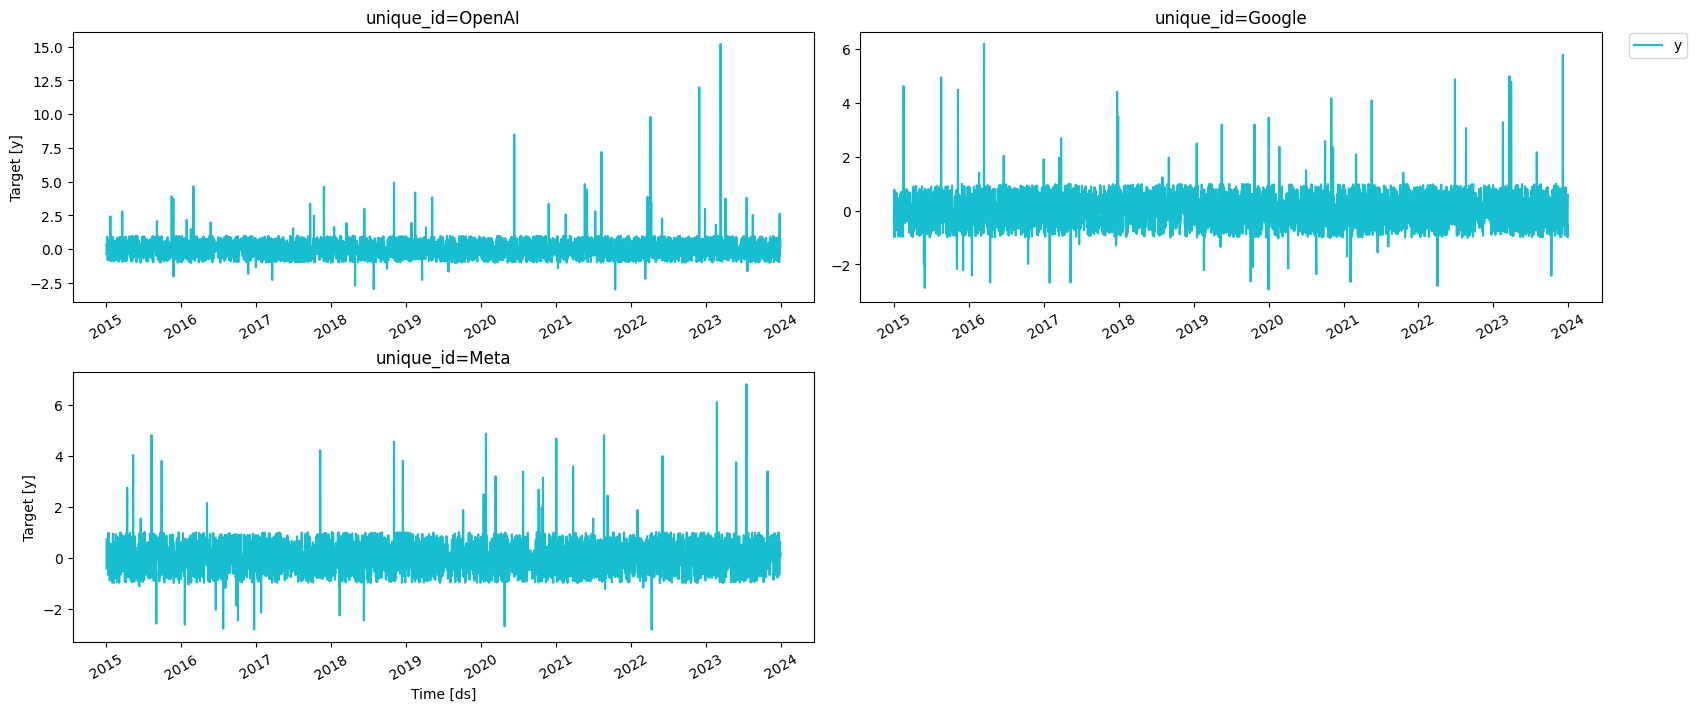

In [102]:
plot_series(df=df, ids=["OpenAI","Google","Meta"])

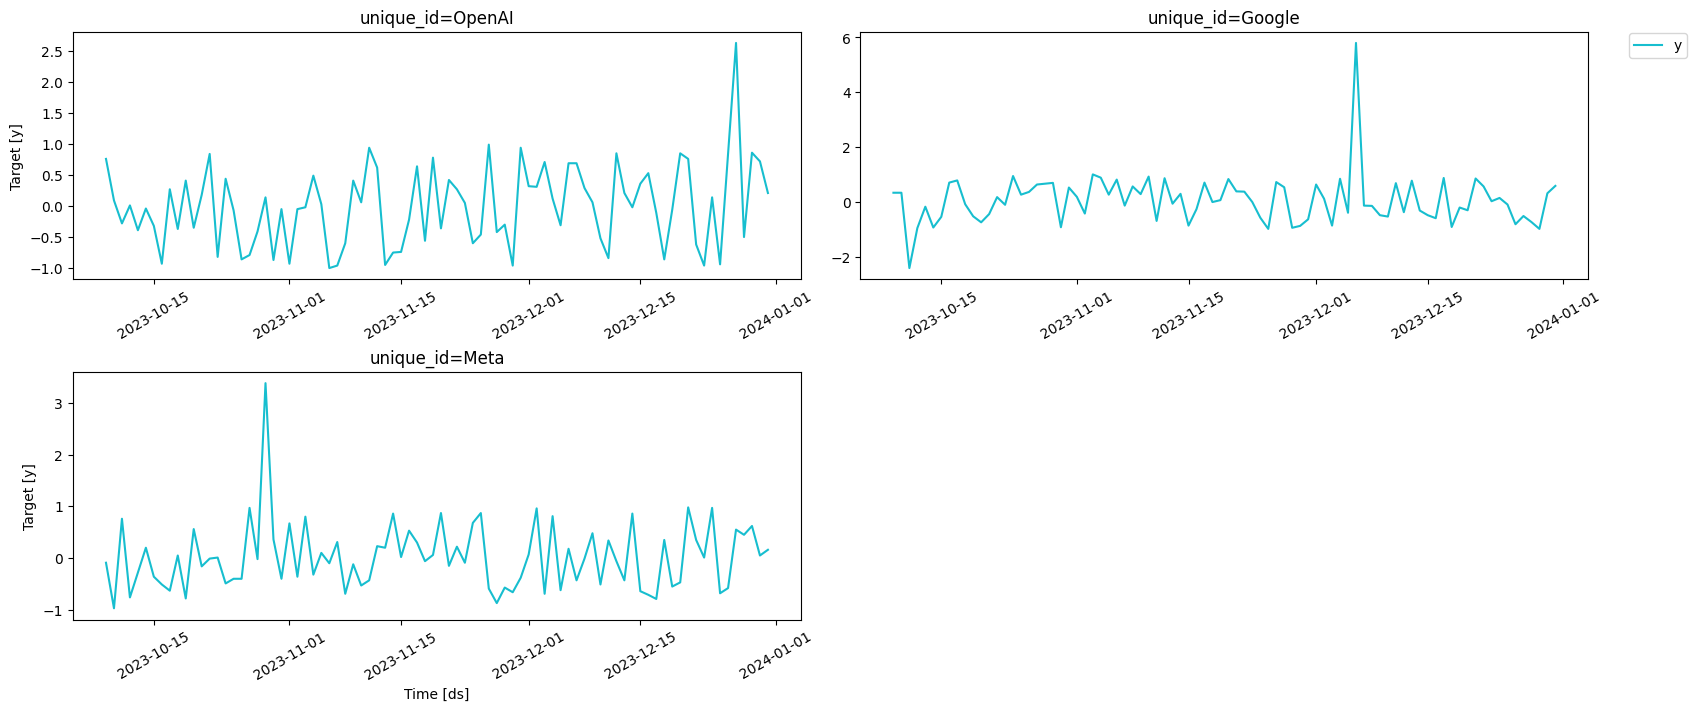

In [120]:
plot_series(df=df, ids=["OpenAI","Google","Meta"], max_insample_length=84)

Baseline models

In [104]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [105]:
horizon = 7 #forecast for next  days

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7), #Take average of last 7 days
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=df)
preds = sf.predict(horizon)

In [106]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Google,2024-01-01,0.58,0.026714,-0.325714,-0.10
1,Google,2024-01-02,0.58,0.026714,-0.325714,-0.82
2,Google,2024-01-03,0.58,0.026714,-0.325714,-0.52
3,Google,2024-01-04,0.58,0.026714,-0.325714,-0.74
4,Google,2024-01-05,0.58,0.026714,-0.325714,-0.99


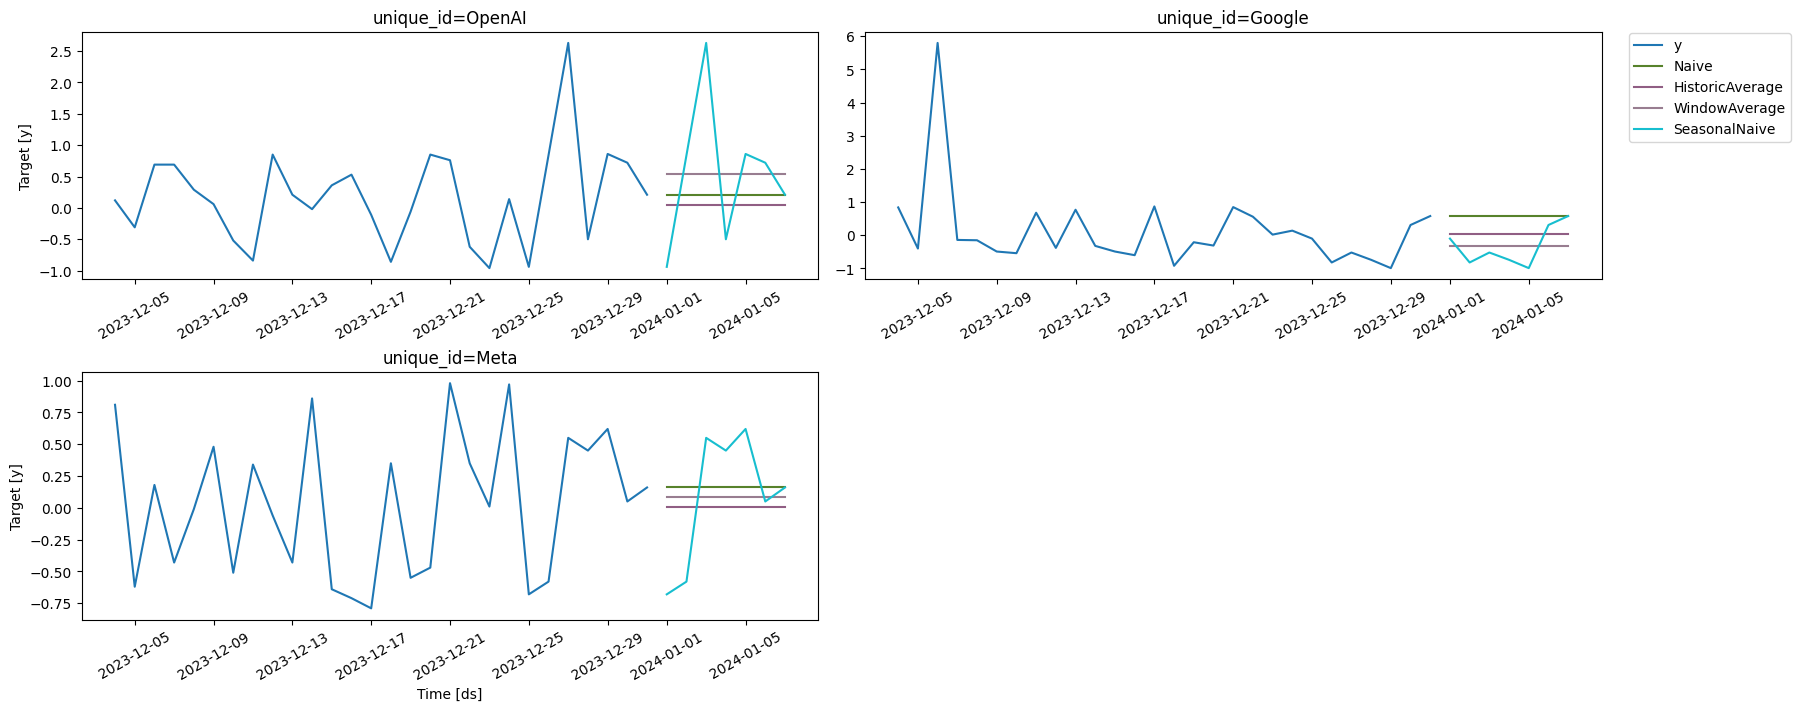

In [107]:
# Plot predictions
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["OpenAI","Google","Meta"],
    max_insample_length=28,
)

Evaluate baseline models

In [108]:
test = df.groupby("unique_id").tail(7) #Last 7 timestamp
train = df.drop(test.index).reset_index(drop=True)

In [109]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [110]:
evaluation = evaluate(
    eval_df,
    metrics=[mae], #mean absolute error
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Google,mae,0.640000,0.591771,0.587959,0.787143
1,Meta,mae,0.888571,0.439341,0.414898,0.532857
2,OpenAI,mae,0.897143,0.939954,1.003061,1.035714


In [111]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,0.808571,0.657022,0.668639,0.785238


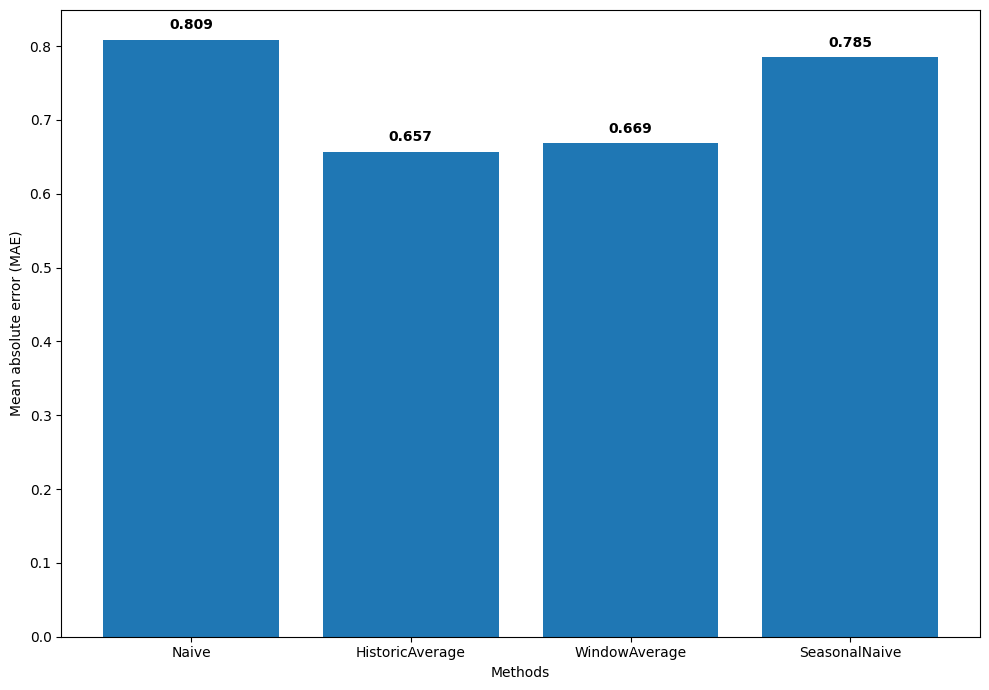

In [112]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10,7))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

HistoricAverage has the least MAE across all the baseline models.

AutoARIMA

In [113]:
from statsforecast.models import AutoARIMA

In [115]:
unique_ids = ["OpenAI", "Google", "Meta"]

small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=small_train)
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Google,mae,0.591260,0.591260,0.640000,0.591771,0.587959,0.787143
1,Meta,mae,0.441429,0.441429,0.888571,0.439341,0.414898,0.532857
2,OpenAI,mae,0.940521,0.940521,0.897143,0.939954,1.003061,1.035714


In [116]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,0.657737,0.657737,0.808571,0.657022,0.668639,0.785238


The best baseline model is still HistoricAverage model.

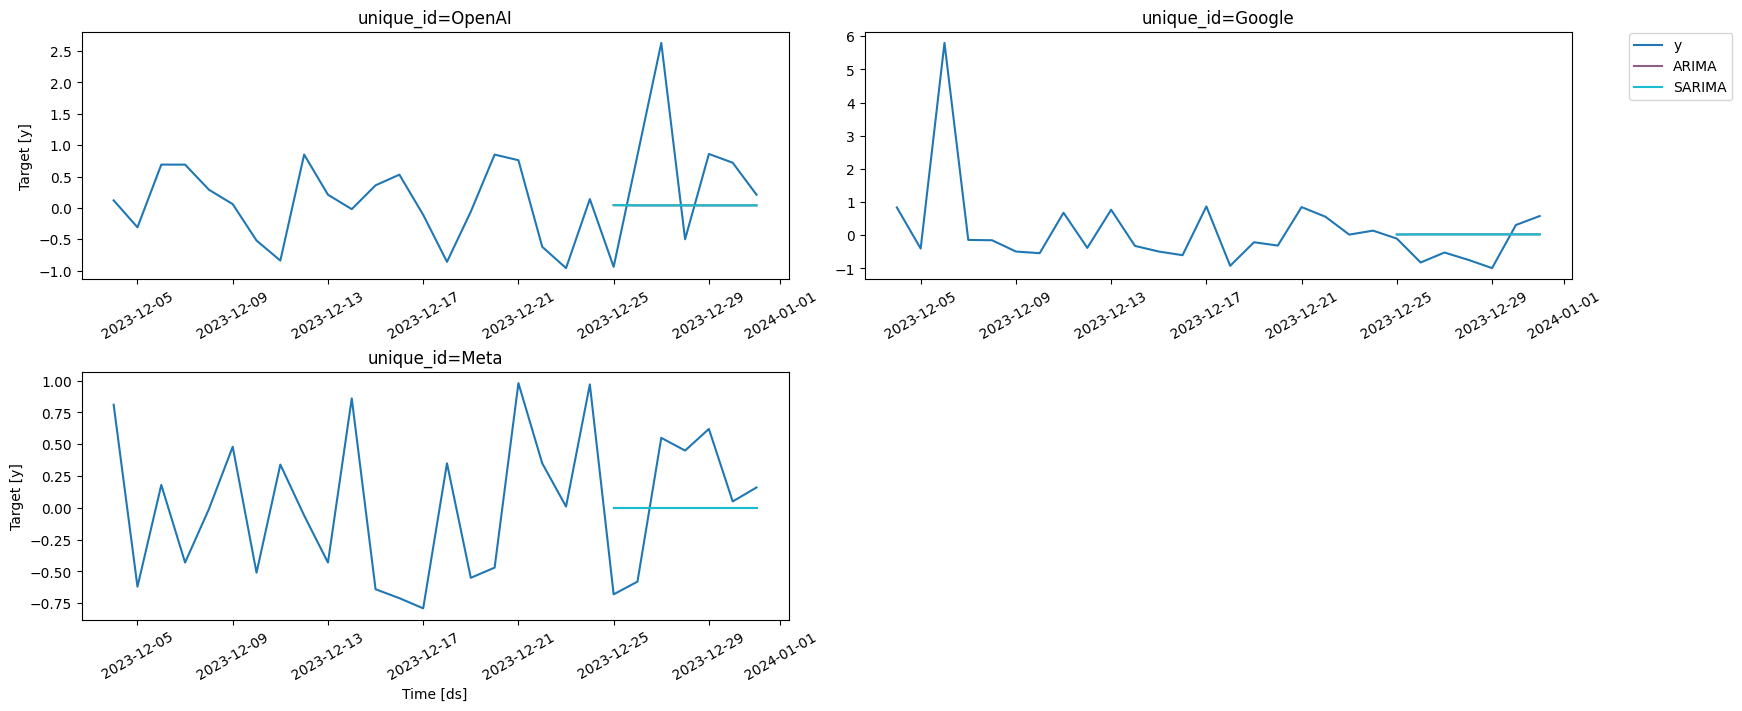

In [ ]:
plot_series(
    df=df,
    forecasts_df=arima_preds,
    ids=["OpenAI", "Google", "Meta"],
    max_insample_length=28,
)

AI financial market stock impact does not have any seasonal pattern.

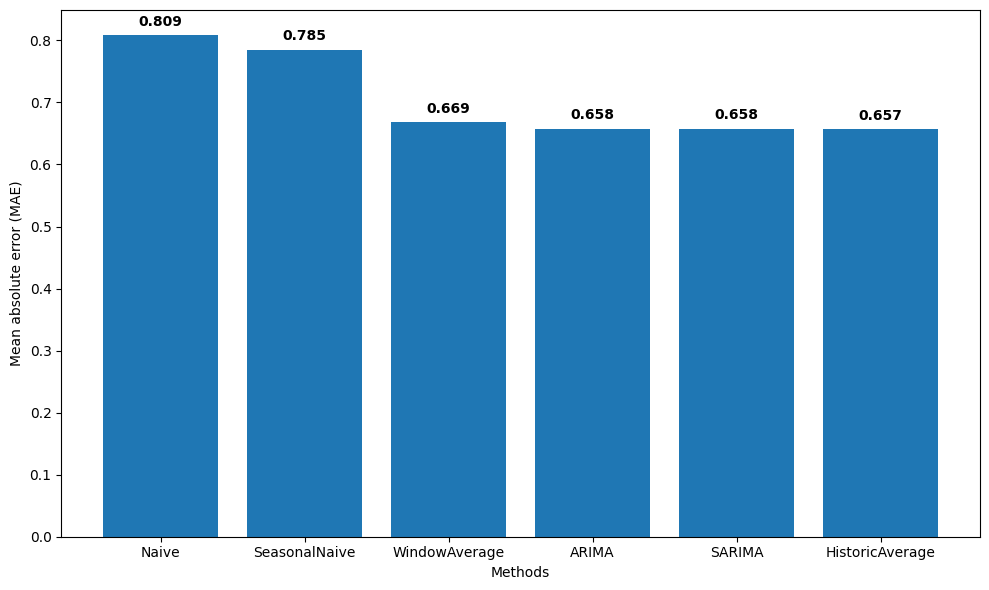

In [119]:
methods = arima_eval.columns[1:].tolist()
values = arima_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x:x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

Cross-validation

In [121]:
small_df = df[df["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(season_length=7, alias='SARIMA'),
    AutoARIMA(seasonal=False, alias='ARIMA'),
    HistoricAverage()
]

sf = StatsForecast(models=models, freq="D")
cv_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=324,
    step_size=horizon,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,SARIMA,ARIMA,HistoricAverage
0,Google,2017-10-16,2017-10-15,-0.67,0.0,0.030480,0.011855
1,Google,2017-10-17,2017-10-15,-0.31,0.0,-0.033415,0.011855
2,Google,2017-10-18,2017-10-15,0.43,0.0,0.036020,0.011855
3,Google,2017-10-19,2017-10-15,-0.89,0.0,-0.038293,0.011855
4,Google,2017-10-20,2017-10-15,-0.53,0.0,0.040235,0.011855


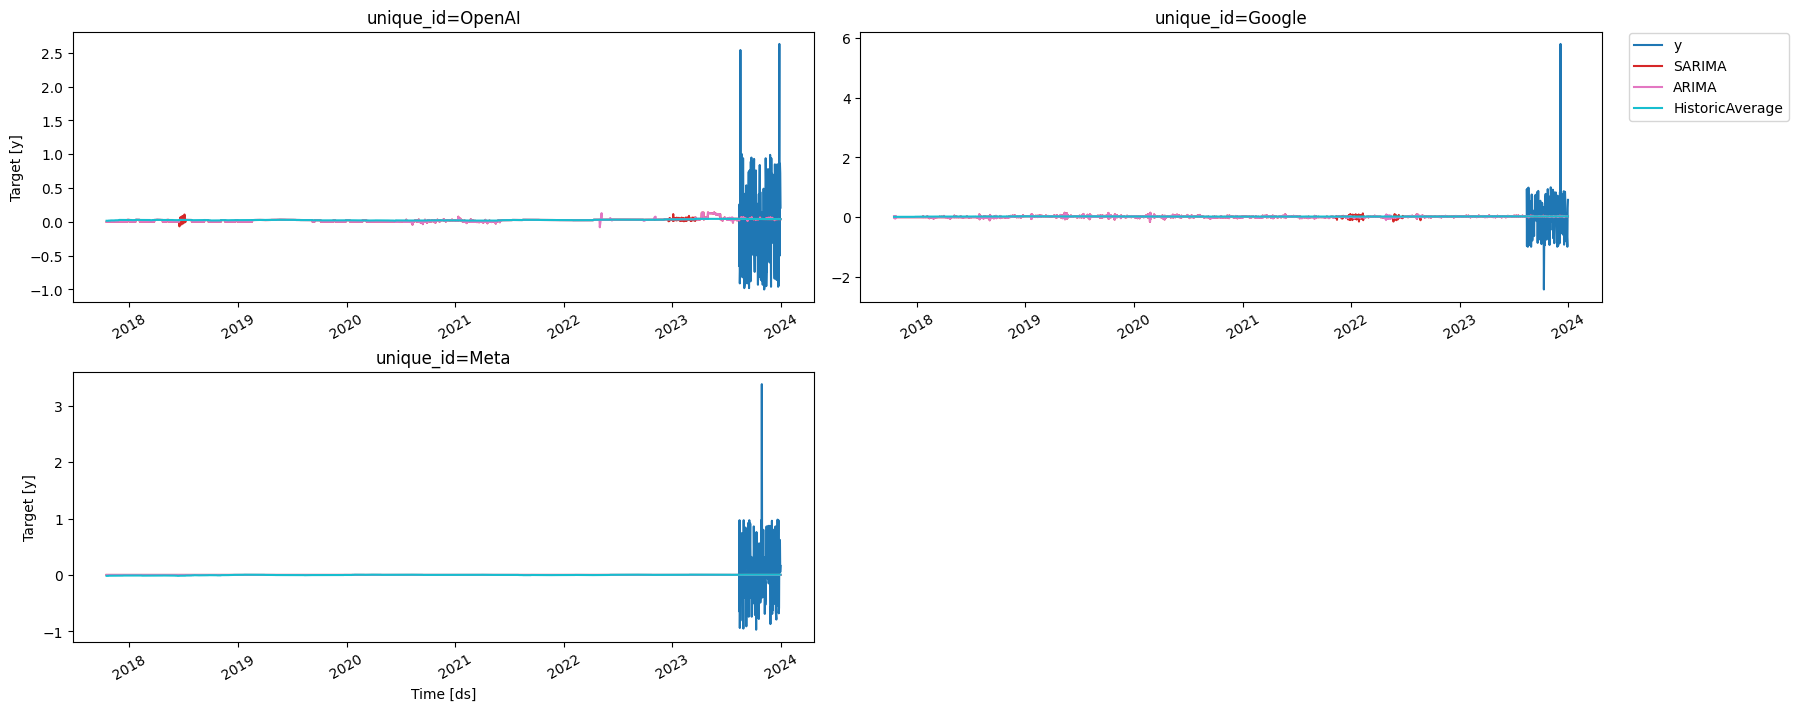

In [122]:
plot_series(
    df=small_df,
    forecasts_df=cv_df.drop(["y", 'cutoff'], axis=1),
    ids=["OpenAI", "Google", "Meta"],
    max_insample_length=140,
)

In [123]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae]
)
cv_eval = cv_eval.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
cv_eval

,metric,SARIMA,ARIMA,HistoricAverage
0,mae,0.545995,0.546063,0.545457


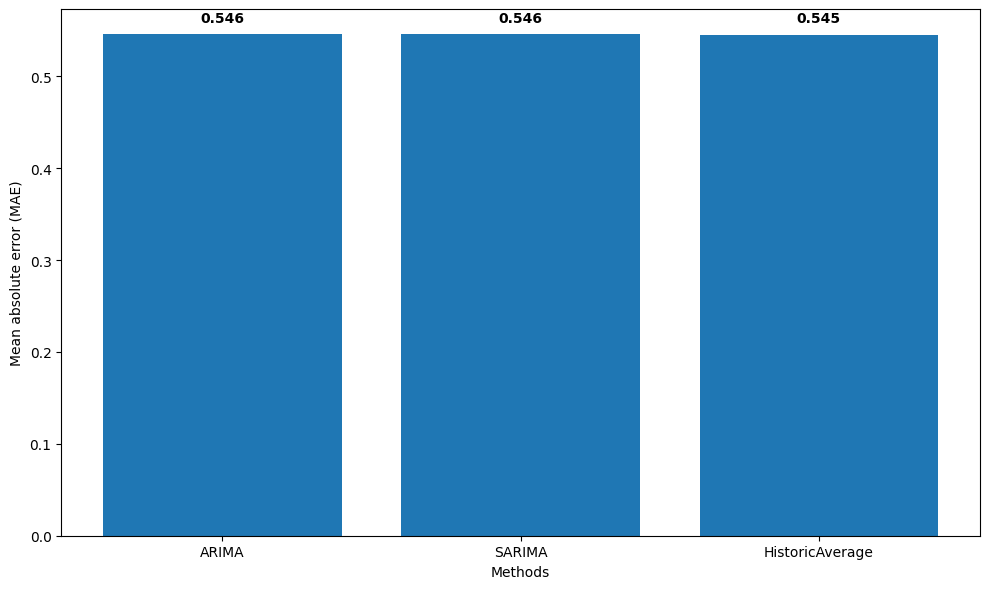

In [124]:
methods = cv_eval.columns[1:].tolist()
values = cv_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x:x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

Forecasting with exogenous features

In [132]:
df = pd.read_csv("historical data/historical_market_data.csv", parse_dates= ["Date"])

df = df.rename(
    columns={
        "Company":"unique_id",
        "Date":"ds",
        "Stock_Impact_%":"y",
        "R&D_Spending_USD_Mn":"spending",
        "AI_Revenue_USD_Mn":"revenue",
        "AI_Revenue_Growth_%":"revenue_growth"
    }
).drop(columns='Event')

print(df.head())

          ds unique_id  spending  revenue  revenue_growth     y
0 2015-01-01    OpenAI      5.92     0.63          -36.82 -0.36
1 2015-01-02    OpenAI      5.41     1.81           80.59  0.41
2 2015-01-03    OpenAI      4.50     0.61          -38.88  0.23
3 2015-01-04    OpenAI      5.45     0.95           -5.34  0.93
4 2015-01-05    OpenAI      3.40     1.48           48.45 -0.09


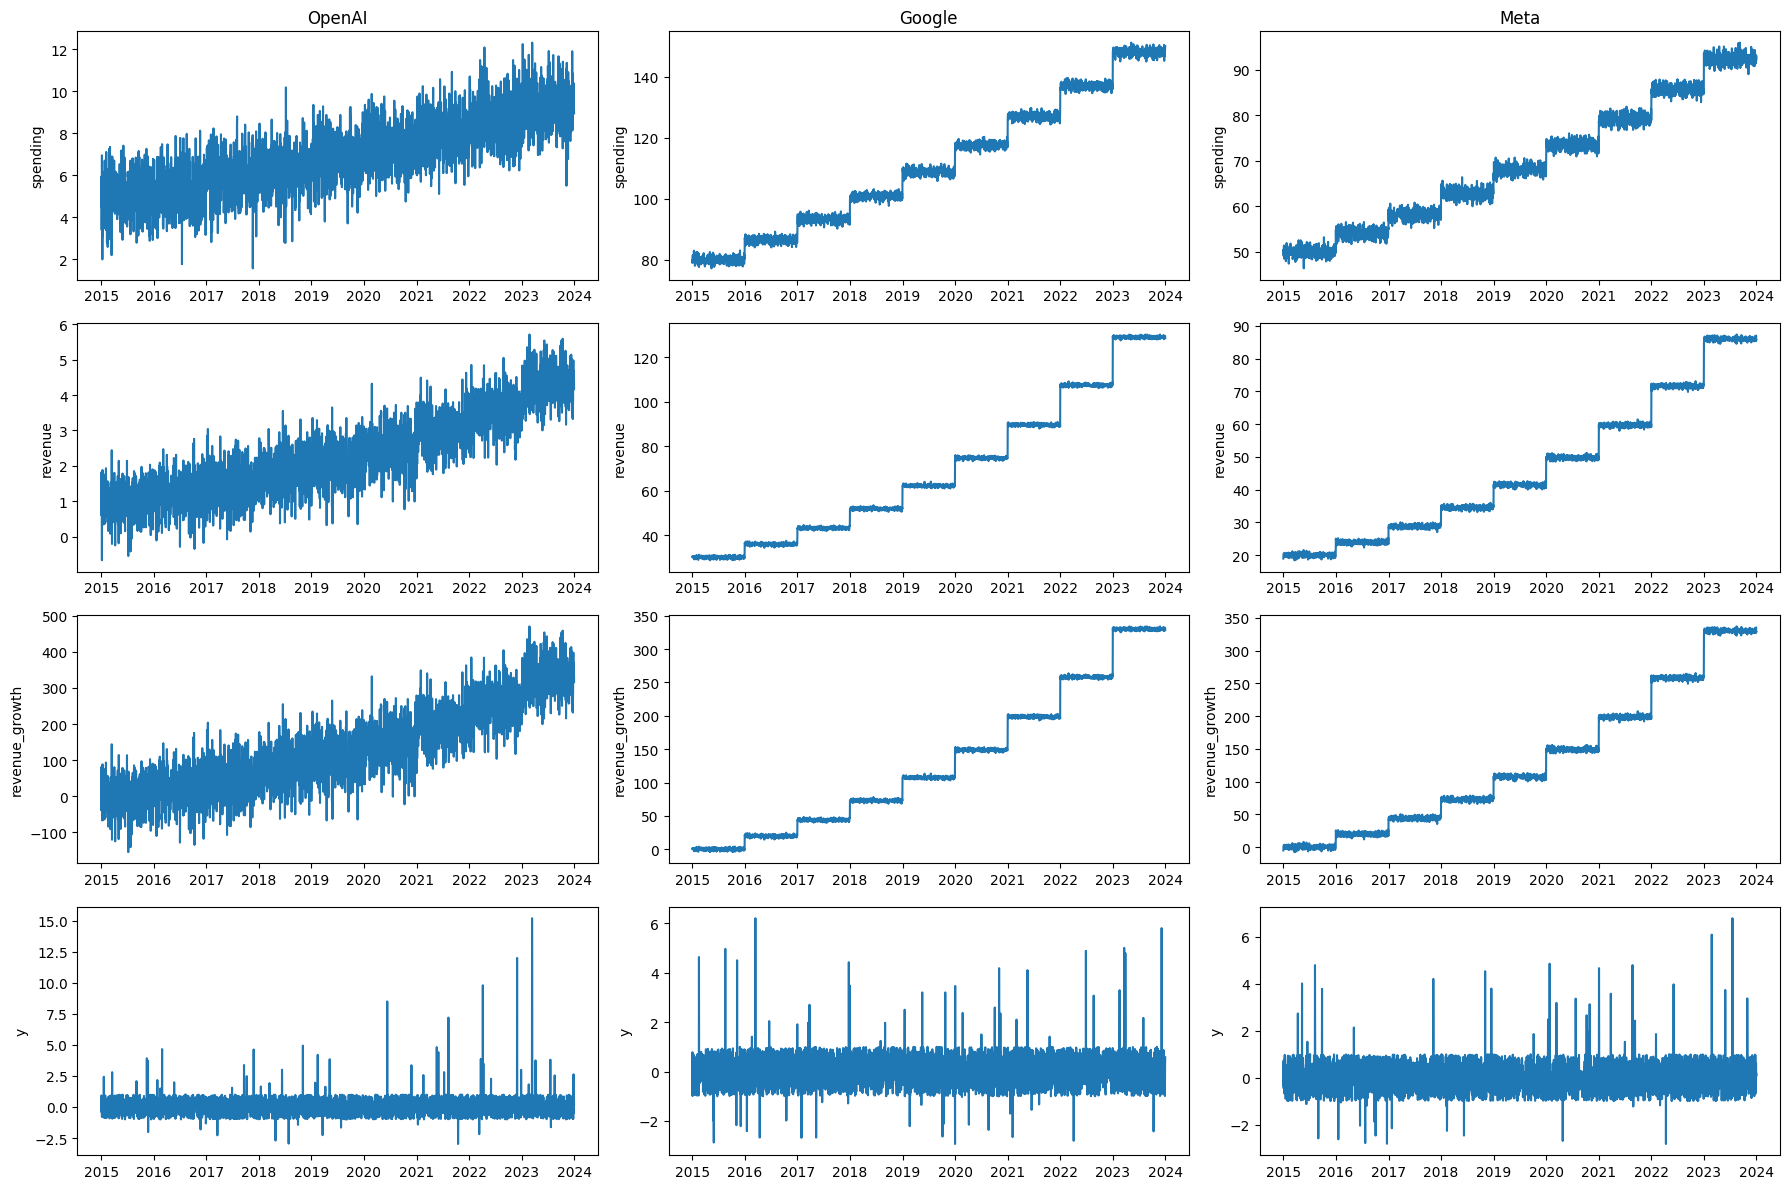

In [133]:
OpenAI_plot_df = df[df["unique_id"] == "OpenAI"]
Google_plot_df = df[df["unique_id"] == "Google"]
Meta_plot_df = df[df["unique_id"] == "Meta"]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))

companies = {
    "OpenAI": OpenAI_plot_df,
    "Google": Google_plot_df,
    "Meta": Meta_plot_df
}

variables = ["spending", "revenue", "revenue_growth", "y"]

for col_idx, (company, company_df) in enumerate(companies.items()):
    for row_idx, var in enumerate(variables):
        ax = axes[row_idx, col_idx]

        ax.plot(company_df["ds"], company_df[var])

        if row_idx == 0:
            ax.set_title(company)

        ax.set_ylabel(var)

plt.tight_layout()
plt.show()

In [134]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [139]:
futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,ds,unique_id,spending,revenue,revenue_growth
3280,2023-12-25,OpenAI,9.87,4.79,379.22
3281,2023-12-26,OpenAI,9.45,4.98,397.91
3282,2023-12-27,OpenAI,9.22,4.46,345.80
3283,2023-12-28,OpenAI,10.38,4.15,314.98
3284,2023-12-29,OpenAI,9.47,4.68,368.50


In [141]:
# Define model
models = [
    AutoARIMA(seasonal=False, alias="ARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)

# Predict with exogenous features
arima_exog_preds = sf.predict(h=horizon, X_df=futr_exog_df)

# Without exogenous features
models = [
    AutoARIMA(seasonal=False, alias="ARIMA")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train.drop(["spending", "revenue", "revenue_growth"], axis=1))
arima_preds = sf.predict(h=horizon)

In [142]:
test_df = test.merge(arima_exog_preds, on=["unique_id", "ds"], how="left").merge(arima_preds, on=["unique_id", "ds"], how="left")
test_df

,ds,unique_id,spending,revenue,revenue_growth,y,ARIMA_exog,ARIMA
0,2023-12-25,OpenAI,9.87,4.79,379.22,-0.94,0.100089,0.044067
1,2023-12-26,OpenAI,9.45,4.98,397.91,0.84,0.104997,0.040104
2,2023-12-27,OpenAI,9.22,4.46,345.80,2.63,0.092304,0.040104
3,2023-12-28,OpenAI,10.38,4.15,314.98,-0.50,0.083963,0.040104
4,2023-12-29,OpenAI,9.47,4.68,368.50,0.86,0.097657,0.040104
5,2023-12-30,OpenAI,9.15,4.54,353.98,0.72,0.094341,0.040104
6,2023-12-31,OpenAI,8.94,4.19,318.97,0.21,0.085839,0.040104
7,2023-12-25,Google,147.75,129.28,330.94,-0.10,0.049575,0.023769
8,2023-12-26,Google,147.10,128.20,327.33,-0.82,0.052057,0.027587
9,2023-12-27,Google,148.29,128.90,329.67,-0.52,0.051671,0.027462


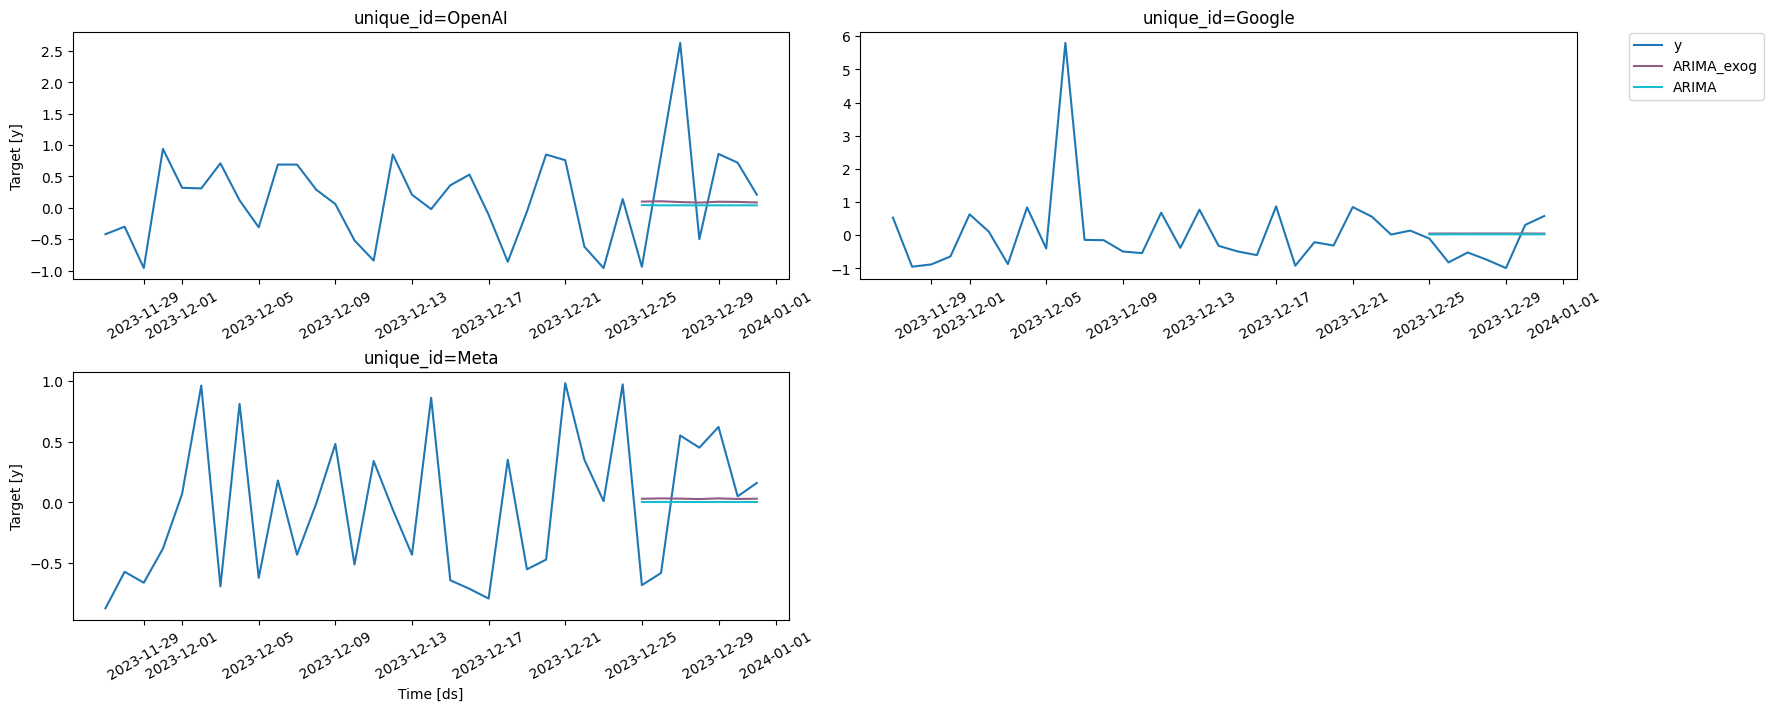

: 

In [ ]:
plot_series(
    df=train,
    forecasts_df=test_df,
    ids=["OpenAI", "Google", "Meta"],
    max_insample_length=28,
    models=["ARIMA_exog", "ARIMA"]
)